# Sales level shift — confronto tra LSTM forecasting e baseline classiche

Questo notebook confronta il detector forecasting-based basato su LSTM con due baseline più semplici:

- **Seasonal Naive T−7**, che usa il valore osservato sette giorni prima;
- **Ridge regression**, addestrata su feature calendariali, di store, esogene e sui lag delle vendite.

Tutti gli approcci sono valutati con la stessa pipeline event-level: residui di previsione, score aggregato, soglie calibrate sulla validation e matching con le finestre ground truth tramite IoU. La ground truth è usata esclusivamente per la valutazione finale.

## Import e dipendenze

Sono importati i path centralizzati del progetto, le librerie per tabelle e grafici e le utility condivise per preprocessing delle baseline, detection e valutazione event-level.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from project_paths import (
    LEVEL_SHIFT_RESULTS_DIR,
    LEVEL_SHIFT_SENSITIVITY_DIR,
    ensure_artifact_directories,
)

from sales_level_shift_utils import (
    add_temporal_split,
    add_baseline_features,
    add_baseline_predictions,
    make_baseline_results_df,
    run_level_shift_detector,
    list_sensitivity_datasets,
)

pd.set_option("display.max_columns", None)

## Configurazione, path e cache

I path degli artifact sono centralizzati in `project_paths.py`. La configurazione del detector coincide con quella della pipeline LSTM principale: nel confronto cambia solo il predittore che genera i residui.

Il CSV `level_shift_classical_baseline_results.csv` è l’unica cache delle baseline. Quando è presente, il notebook non riesegue feature engineering, addestramento della Ridge, previsioni o detection. `FORCE_RECOMPUTE_BASELINES = True` rigenera il CSV completo.

In [3]:
ensure_artifact_directories()

BASE_SENSITIVITY_PATH = LEVEL_SHIFT_SENSITIVITY_DIR

# Risultati LSTM prodotti dal notebook di severity analysis.
LSTM_SEVERITY_OUTPUT_DIR = LEVEL_SHIFT_RESULTS_DIR / "lstm_severity"
LSTM_RESULTS_PATH = LSTM_SEVERITY_OUTPUT_DIR / "level_shift_severity_raw_results.csv"

OUTPUT_DIR = LEVEL_SHIFT_RESULTS_DIR / "baseline_comparison"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for path in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Modello LSTM finale scelto dal tuning.
LSTM_MODEL_NAME = "lstm_forecasting"

# Detector base.
SCORE_WINDOW = 7
N_STD = 3.5
MIN_CONSECUTIVE = 3
GAP_TOLERANCE = 1
IOU_THRESHOLD = 0.20

# Baseline classiche.
RIDGE_ALPHA = 1.0
TRAIN_SIZE = 0.70
VAL_SIZE = 0.10
FORCE_RECOMPUTE_BASELINES = False

BASELINE_RESULTS_PATH = OUTPUT_DIR / "level_shift_classical_baseline_results.csv"
FULL_COMPARISON_PATH = OUTPUT_DIR / "level_shift_full_model_comparison.csv"
POOLED_SUMMARY_PATH = TABLES_DIR / "level_shift_model_comparison_pooled.csv"

CONFIG = {
    "score_window": SCORE_WINDOW,
    "n_std": N_STD,
    "min_consecutive": MIN_CONSECUTIVE,
    "gap_tolerance": GAP_TOLERANCE,
    "iou_threshold": IOU_THRESHOLD,
    "ridge_alpha": RIDGE_ALPHA,
}

print("BASE_SENSITIVITY_PATH:", BASE_SENSITIVITY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
CONFIG

BASE_SENSITIVITY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\level_shift\sensitivity
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\baseline_comparison


{'score_window': 7,
 'n_std': 3.5,
 'min_consecutive': 3,
 'gap_tolerance': 1,
 'iou_threshold': 0.2,
 'ridge_alpha': 1.0}

## Dataset di sensitivity

Ogni riga dell’indice corrisponde a una combinazione di direzione, durata, moltiplicatore e seed. Gli eventi `level_shift` sono iniettati nel test set; train e validation restano il riferimento per l’addestramento della Ridge e per la calibrazione delle soglie.

In [4]:
if not BASE_SENSITIVITY_PATH.exists():
    raise FileNotFoundError(f"Cartella dei dataset non trovata: {BASE_SENSITIVITY_PATH}")

datasets_df = list_sensitivity_datasets(BASE_SENSITIVITY_PATH)

# Ordine stabile per risultati e cache riproducibili.
datasets_df = datasets_df.sort_values(
    ["direction", "duration", "multiplier", "seed"]
).reset_index(drop=True)

print("Numero dataset:", len(datasets_df))
display(datasets_df.head())

Numero dataset: 280


,path,direction,duration,multiplier,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,46


## Feature delle baseline

La Seasonal Naive usa `sales_lag_7`. La Ridge usa lag delle vendite, medie mobili, calendario, store e covariate esogene. Le feature legate alle vendite sono costruite solo da osservazioni precedenti al giorno da prevedere.

In [5]:
# Lag brevi e multipli settimanali usati dalla Ridge.
SALES_LAGS = list(range(1, 8)) + [14, 21, 28]

In [6]:
RIDGE_NUM_FEATURES = (
    [f"sales_lag_{lag}" for lag in SALES_LAGS]
    + [
        "sales_rm_7",
        "sales_rm_30",
        "time_idx",
        "oil_price",
        "consumer_confidence",
        "fao",
    ]
)

RIDGE_CAT_FEATURES = [
    "store_id",
    "week_day",
    "month",
    "day",
    "holiday",
    "actual_holiday",
    "pre_holiday",
]

TARGET_COL = "daily_total_sales"

GT_COL_CANDIDATES = [
    "is_level_shift_anomaly",
    "lsa_type",
    "lsa_mult",
    "lsa_event_id",
    "lsa_day_in_event",
    "lsa_duration",
    "lsa_severity",
    "severity_class",
]

## Valutazione delle baseline

Per ogni dataset, le due baseline producono previsioni su validation e test. I residui passano poi nella stessa pipeline di score, soglia, aggregazione in finestre e valutazione event-level usata per la LSTM.

In [7]:
def evaluate_baselines_on_single_dataset(row):
    # Ogni baseline viene addestrata e valutata sullo stesso dataset.
    df = pd.read_csv(row["path"])
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

    # Split temporali per store: training, validation e test.
    df = add_temporal_split(
        df,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )
    # Feature delle baseline costruite solo da vendite passate.
    df = add_baseline_features(
        df,
        sales_lags=SALES_LAGS,
    )
    df = add_baseline_predictions(
        df,
        ridge_num_features=RIDGE_NUM_FEATURES,
        ridge_cat_features=RIDGE_CAT_FEATURES,
        ridge_alpha=RIDGE_ALPHA,
        target_col=TARGET_COL,
    )

    # Le due baseline condividono preprocessing, detector e valutazione.
    baseline_specs = [
        ("seasonal_naive_t7", "y_pred_seasonal_naive_t7"),
        ("ridge_regression", "y_pred_ridge"),
    ]

    rows = []

    for model_name, pred_col in baseline_specs:
        val_results = make_baseline_results_df(
            df,
            split="val",
            pred_col=pred_col,
            target_col=TARGET_COL,
            gt_col_candidates=GT_COL_CANDIDATES,
        )

        test_results = make_baseline_results_df(
            df,
            split="test",
            pred_col=pred_col,
            target_col=TARGET_COL,
            gt_col_candidates=GT_COL_CANDIDATES,
        )

        summary = run_level_shift_detector(
            val_results,
            test_results,
            model_name=model_name,
            score_window=SCORE_WINDOW,
            n_std=N_STD,
            min_consecutive=MIN_CONSECUTIVE,
            gap_tolerance=GAP_TOLERANCE,
            iou_threshold=IOU_THRESHOLD,
        )

        summary.update({
            "direction": row["direction"],
            "duration": row["duration"],
            "multiplier": row["multiplier"],
            "seed": row["seed"],
            "csv_path": str(row["path"]),
        })

        rows.append(summary)

    return rows



# Il CSV finale evita di rieseguire le baseline dopo un'esecuzione completa.
if BASELINE_RESULTS_PATH.exists() and not FORCE_RECOMPUTE_BASELINES:
    baseline_results = pd.read_csv(BASELINE_RESULTS_PATH)
else:
    baseline_rows = []

    for i, row in datasets_df.iterrows():
        print(
            f"[{i + 1}/{len(datasets_df)}] "
            f"{row['direction']} | "
            f"dur={row['duration']} | "
            f"mult={row['multiplier']} | "
            f"seed={row['seed']}"
        )

        dataset_rows = evaluate_baselines_on_single_dataset(row)
        baseline_rows.extend(dataset_rows)

    baseline_results = pd.DataFrame(baseline_rows)
    baseline_results.to_csv(BASELINE_RESULTS_PATH, index=False)

print("Baseline results:", baseline_results.shape)
display(baseline_results.head())
BASELINE_RESULTS_PATH

Baseline results: (560, 22)


,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_det_offset_start,mean_detection_det_offset_end,model,score_window,n_std,min_consecutive,gap_tolerance,iou_threshold,direction,duration,multiplier,seed,csv_path
0,40,15,5,10,35,0.333333,0.125,0.181818,0.653492,-3.400000,0.200000,seasonal_naive_t7,7,3.5,3,1,0.2,decrease,7,0.7,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
1,40,44,38,6,2,0.863636,0.950,0.904762,0.522449,-4.263158,2.447368,ridge_regression,7,3.5,3,1,0.2,decrease,7,0.7,42,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
2,40,13,3,10,37,0.230769,0.075,0.113208,0.712963,-2.000000,1.000000,seasonal_naive_t7,7,3.5,3,1,0.2,decrease,7,0.7,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
3,40,47,37,10,3,0.787234,0.925,0.850575,0.516322,-4.459459,2.378378,ridge_regression,7,3.5,3,1,0.2,decrease,7,0.7,43,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...
4,40,16,6,10,34,0.375000,0.150,0.214286,0.696008,-2.666667,0.333333,seasonal_naive_t7,7,3.5,3,1,0.2,decrease,7,0.7,44,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/baseline_comparison/level_shift_classical_baseline_results.csv')

## Risultati della LSTM

Le metriche LSTM non vengono ricalcolate qui: il notebook carica i risultati della severity analysis nella configurazione base del detector.

In [8]:
def load_lstm_base_results():
    if not LSTM_RESULTS_PATH.exists():
        raise FileNotFoundError(
            "Risultati LSTM non trovati. "
            "Esegui prima 02_level_shift_severity."
        )

    lstm = pd.read_csv(LSTM_RESULTS_PATH)

    required_cols = [
        "direction",
        "duration",
        "multiplier",
        "seed",
        "n_gt_events",
        "n_detected_events",
        "tp",
        "fp",
        "fn",
        "precision",
        "recall",
        "f1",
        "mean_iou",
    ]

    missing_cols = [col for col in required_cols if col not in lstm.columns]

    if missing_cols:
        raise ValueError(
            "Il file LSTM non ha lo schema atteso.\n"
            f"File: {LSTM_RESULTS_PATH}\n"
            f"Colonne mancanti: {missing_cols}"
        )

    if lstm.empty:
        raise ValueError(
            f"Il file dei risultati LSTM è vuoto: {LSTM_RESULTS_PATH}"
        )

    lstm["model"] = LSTM_MODEL_NAME
    lstm["score_window"] = SCORE_WINDOW
    lstm["n_std"] = N_STD
    lstm["min_consecutive"] = MIN_CONSECUTIVE
    lstm["gap_tolerance"] = GAP_TOLERANCE
    lstm["iou_threshold"] = IOU_THRESHOLD

    print("LSTM results source:", LSTM_RESULTS_PATH)
    print("LSTM rows:", len(lstm))

    return lstm


lstm_results = load_lstm_base_results()
display(lstm_results.head())

LSTM results source: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\lstm_severity\level_shift_severity_raw_results.csv
LSTM rows: 280


,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,mean_detection_det_offset_start,mean_detection_det_offset_end,direction,duration,multiplier,severity_class,seed,model,score_window,n_std,min_consecutive,gap_tolerance,iou_threshold
0,40,66,40,26,0,0.606061,1.0,0.754717,0.447984,-5.625,3.050,decrease,7,0.7,hard,42,lstm_forecasting,7,3.5,3,1,0.2
1,40,63,40,23,0,0.634921,1.0,0.776699,0.443395,-5.675,3.300,decrease,7,0.7,hard,43,lstm_forecasting,7,3.5,3,1,0.2
2,40,64,40,24,0,0.625000,1.0,0.769231,0.440574,-5.750,3.300,decrease,7,0.7,hard,44,lstm_forecasting,7,3.5,3,1,0.2
3,40,61,40,21,0,0.655738,1.0,0.792079,0.446315,-5.725,3.075,decrease,7,0.7,hard,45,lstm_forecasting,7,3.5,3,1,0.2
4,40,66,40,26,0,0.606061,1.0,0.754717,0.450116,-5.750,2.850,decrease,7,0.7,hard,46,lstm_forecasting,7,3.5,3,1,0.2


## Dataset finale di confronto

Le righe delle due baseline e della LSTM vengono uniformate a uno schema comune e concatenate in un unico dataframe, usato per tabelle, aggregazioni e figure.

In [9]:
COMMON_COLS = [
    "model",
    "direction",
    "duration",
    "multiplier",
    "seed",
    "score_window",
    "n_std",
    "min_consecutive",
    "gap_tolerance",
    "iou_threshold",
    "n_gt_events",
    "n_detected_events",
    "tp",
    "fp",
    "fn",
    "precision",
    "recall",
    "f1",
    "mean_iou",
]

# Allinea lo schema delle baseline e della LSTM prima della concatenazione.
for col in COMMON_COLS:
    if col not in baseline_results.columns:
        baseline_results[col] = np.nan
    if col not in lstm_results.columns:
        lstm_results[col] = np.nan

baseline_fixed = baseline_results[COMMON_COLS].copy()
lstm_fixed = lstm_results[COMMON_COLS].copy()

full_comparison = pd.concat(
    [baseline_fixed, lstm_fixed],
    ignore_index=True,
)

full_comparison.to_csv(FULL_COMPARISON_PATH, index=False)

print("Full comparison:", full_comparison.shape)
display(full_comparison.head())
FULL_COMPARISON_PATH

Full comparison: (840, 19)


,model,direction,duration,multiplier,seed,score_window,n_std,min_consecutive,gap_tolerance,iou_threshold,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou
0,seasonal_naive_t7,decrease,7,0.7,42,7,3.5,3,1,0.2,40,15,5,10,35,0.333333,0.125,0.181818,0.653492
1,ridge_regression,decrease,7,0.7,42,7,3.5,3,1,0.2,40,44,38,6,2,0.863636,0.950,0.904762,0.522449
2,seasonal_naive_t7,decrease,7,0.7,43,7,3.5,3,1,0.2,40,13,3,10,37,0.230769,0.075,0.113208,0.712963
3,ridge_regression,decrease,7,0.7,43,7,3.5,3,1,0.2,40,47,37,10,3,0.787234,0.925,0.850575,0.516322
4,seasonal_naive_t7,decrease,7,0.7,44,7,3.5,3,1,0.2,40,16,6,10,34,0.375000,0.150,0.214286,0.696008


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/baseline_comparison/level_shift_full_model_comparison.csv')

## Sintesi pooled per modello

Le metriche principali sono ottenute sommando `TP`, `FP` e `FN` su tutti i run dello stesso modello. Precision, recall e \(F_1\) sono quindi calcolati sui conteggi aggregati; la IoU media è pesata per il numero di true positive.

In [10]:
def safe_div(num, den):
    return np.nan if den == 0 else num / den


def pooled_f1(precision, recall):
    if pd.isna(precision) or pd.isna(recall):
        return np.nan
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def weighted_mean(values, weights):
    values = pd.Series(values)
    weights = pd.Series(weights)

    mask = values.notna() & weights.notna() & (weights > 0)

    if not mask.any():
        return np.nan

    return np.average(values[mask], weights=weights[mask])


def build_pooled_model_summary(df):
    # Precision, recall e F1 derivano dai conteggi pooled, non dalle medie dei run.
    rows = []

    for model_name, g in df.groupby("model"):
        tp = int(g["tp"].sum())
        fp = int(g["fp"].sum())
        fn = int(g["fn"].sum())

        precision = safe_div(tp, tp + fp)
        recall = safe_div(tp, tp + fn)
        f1 = pooled_f1(precision, recall)

        rows.append({
            "model": model_name,
            "n_runs": len(g),
            "n_gt_events": int(g["n_gt_events"].sum()),
            "n_detected_events": int(g["n_detected_events"].sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "mean_iou": weighted_mean(g["mean_iou"], g["tp"]),
            "f1_run_mean": g["f1"].mean(),
            "f1_run_std": g["f1"].std(),
        })

    summary = pd.DataFrame(rows)
    summary = summary.sort_values("f1", ascending=False).reset_index(drop=True)

    return summary


model_summary_pooled = build_pooled_model_summary(full_comparison)

metric_cols = [
    "precision",
    "recall",
    "f1",
    "mean_iou",
    "f1_run_mean",
    "f1_run_std",
]

model_summary_display = model_summary_pooled.copy()
model_summary_display[metric_cols] = model_summary_display[metric_cols].round(3)

model_summary_display.to_csv(POOLED_SUMMARY_PATH, index=False)

display(model_summary_display)
POOLED_SUMMARY_PATH

,model,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou,f1_run_mean,f1_run_std
0,lstm_forecasting,280,11200,9211,7601,1610,3599,0.825,0.679,0.745,0.641,0.700,0.295
1,ridge_regression,280,11200,6756,5422,1334,5778,0.803,0.484,0.604,0.671,0.561,0.316
2,seasonal_naive_t7,280,11200,790,406,384,10794,0.514,0.036,0.068,0.561,0.123,0.106


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/baseline_comparison/tables/level_shift_model_comparison_pooled.csv')

## Esportazione LaTeX

La tabella esportata contiene i conteggi event-level e le metriche pooled principali, con nomi dei modelli già pronti per l’inserimento nella tesi.

In [11]:
MODEL_NAME_MAP = {
    "lstm_forecasting": "LSTM",
    "seasonal_naive_t7": "Seasonal Naive",
    "ridge_regression": "Ridge",
}

latex_table = model_summary_pooled[[
    "model",
    "n_gt_events",
    "n_detected_events",
    "tp",
    "fp",
    "fn",
    "precision",
    "recall",
    "f1",
    "mean_iou",
]].copy()

# I nomi vengono formattati solo per l'output LaTeX.
latex_table["model"] = latex_table["model"].replace(MODEL_NAME_MAP)

latex_table = latex_table.rename(
    columns={
        "model": "Modello",
        "n_gt_events": "Eventi GT",
        "n_detected_events": "Eventi rilevati",
        "tp": "TP",
        "fp": "FP",
        "fn": "FN",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "$F_1$",
        "mean_iou": "IoU media",
    }
)

for col in ["Precision", "Recall", "$F_1$", "IoU media"]:
    latex_table[col] = latex_table[col].map(
        lambda x: "--" if pd.isna(x) else f"{x:.3f}"
    )

latex_output_path = TABLES_DIR / "level_shift_model_comparison_pooled.tex"

latex_table.to_latex(
    latex_output_path,
    index=False,
    escape=False,
    column_format="lrrrrrrrrr",
)

display(latex_table)
latex_output_path

,Modello,Eventi GT,Eventi rilevati,TP,FP,FN,Precision,Recall,$F_1$,IoU media
0,LSTM,11200,9211,7601,1610,3599,0.825,0.679,0.745,0.641
1,Ridge,11200,6756,5422,1334,5778,0.803,0.484,0.604,0.671
2,Seasonal Naive,11200,790,406,384,10794,0.514,0.036,0.068,0.561


WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/baseline_comparison/tables/level_shift_model_comparison_pooled.tex')

## Analisi per durata, moltiplicatore e direzione

Le aggregazioni per durata, moltiplicatore e direzione mostrano come cambia il confronto tra modelli al variare delle caratteristiche dello shift.

In [12]:
def build_pooled_comparison(df, group_cols):
    # Aggrega i conteggi prima di ricalcolare le metriche.
    g = (
        df
        .groupby(group_cols, as_index=False)
        .agg(
            n_runs=("seed", "count"),
            n_gt_events=("n_gt_events", "sum"),
            n_detected_events=("n_detected_events", "sum"),
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
        )
    )

    g["precision_pooled"] = g["tp"] / (g["tp"] + g["fp"])
    g["recall_pooled"] = g["tp"] / (g["tp"] + g["fn"])

    den = g["precision_pooled"] + g["recall_pooled"]

    g["f1_pooled"] = np.where(
        den > 0,
        2 * g["precision_pooled"] * g["recall_pooled"] / den,
        np.nan,
    )

    return g


comparison_by_duration = build_pooled_comparison(
    full_comparison,
    ["model", "duration"],
)

comparison_by_multiplier = build_pooled_comparison(
    full_comparison,
    ["model", "multiplier"],
)

comparison_by_direction = build_pooled_comparison(
    full_comparison,
    ["model", "direction"],
)

comparison_by_duration.to_csv(
    TABLES_DIR / "level_shift_comparison_by_duration.csv",
    index=False,
)

comparison_by_multiplier.to_csv(
    TABLES_DIR / "level_shift_comparison_by_multiplier.csv",
    index=False,
)

comparison_by_direction.to_csv(
    TABLES_DIR / "level_shift_comparison_by_direction.csv",
    index=False,
)

display(comparison_by_duration.head())
display(comparison_by_multiplier.head())

,model,duration,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled
0,lstm_forecasting,7,70,2800,2138,1773,365,1027,0.829280,0.633214,0.718104
1,lstm_forecasting,10,70,2800,2271,1887,384,913,0.830911,0.673929,0.744232
2,lstm_forecasting,14,70,2800,2323,1932,391,868,0.831683,0.690000,0.754246
3,lstm_forecasting,21,70,2800,2479,2009,470,791,0.810407,0.717500,0.761129
4,ridge_regression,7,70,2800,1494,1187,307,1613,0.794511,0.423929,0.552864


,model,multiplier,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision_pooled,recall_pooled,f1_pooled
0,lstm_forecasting,0.700,20,800,1315,800,515,0,0.608365,1.00000,0.756501
1,lstm_forecasting,0.800,20,800,1031,800,231,0,0.775946,1.00000,0.873839
2,lstm_forecasting,0.850,20,800,937,799,138,1,0.852721,0.99875,0.919977
3,lstm_forecasting,0.900,20,800,734,617,117,183,0.840599,0.77125,0.804433
4,lstm_forecasting,0.925,20,800,362,294,68,506,0.812155,0.36750,0.506024


## Grafici

Il dashboard confronta precision, recall e \(F_1\) pooled per ciascun moltiplicatore. I casi con moltiplicatore minore e maggiore di uno sono tracciati separatamente per non suggerire continuità attraverso il caso normale.

C:\Users\ciok4\AppData\Local\Temp\ipykernel_87744\1692231934.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.91])


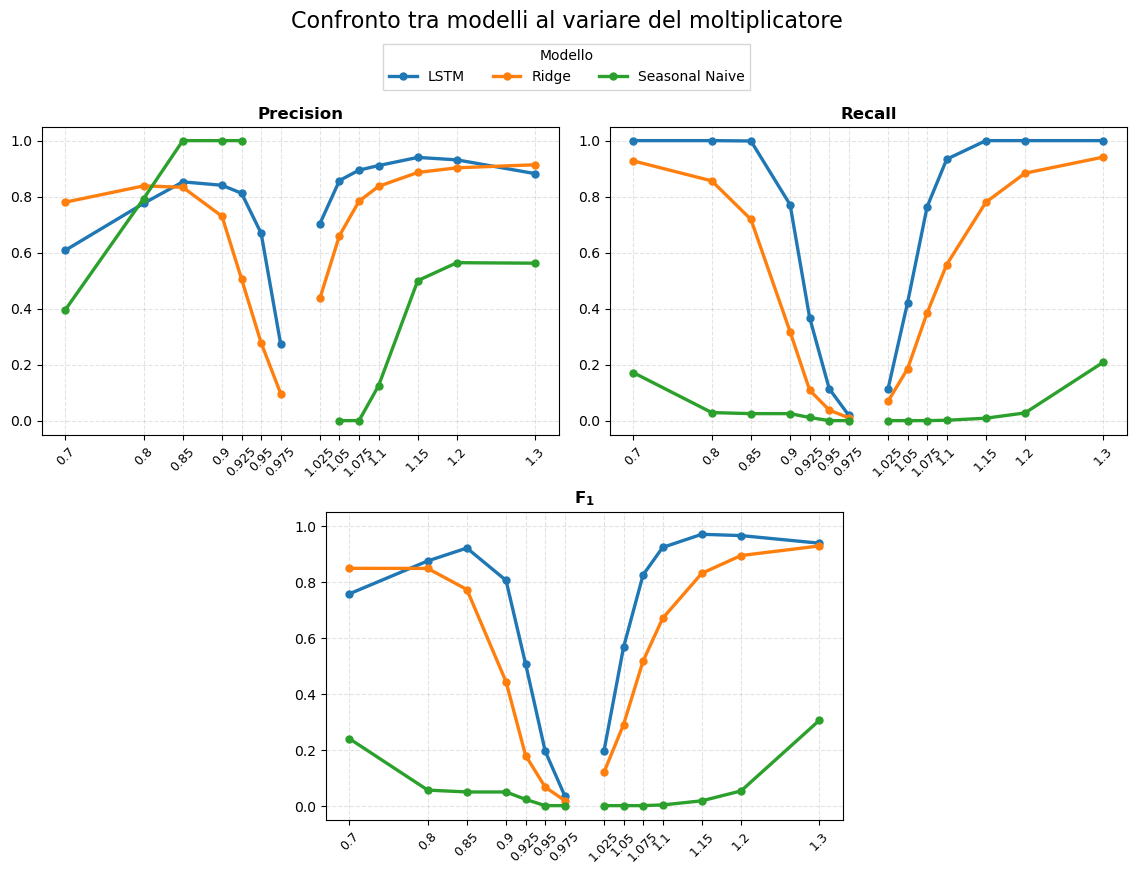

WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/baseline_comparison/figures/level_shift_model_comparison_dashboard_by_multiplier.png')

In [13]:
def model_label(model_name):
    if model_name == "lstm_forecasting":
        return "LSTM"

    return MODEL_NAME_MAP.get(model_name, model_name)


def format_multiplier_tick(x):
    return f"{x:.3f}".rstrip("0").rstrip(".")


def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    return path


def prepare_plot_comparison_df(comparison_df, metric):
    df = comparison_df.copy()

    if metric in ["recall_pooled", "f1_pooled"]:
        df[metric] = df[metric].fillna(0.0)

    return df


def plot_metric_by_multiplier_on_axis(
    ax,
    comparison_df,
    metric,
    title,
    linewidth=2.4,
    marker_size=5,
):
    df = prepare_plot_comparison_df(
        comparison_df,
        metric=metric,
    )

    for model_name, g in df.groupby("model"):
        g = g.sort_values("multiplier")

        # Evita una linea continua attraverso il caso normale m = 1.
        decrease_part = g[g["multiplier"] < 1].copy()
        increase_part = g[g["multiplier"] > 1].copy()

        color = None

        if not decrease_part.empty:
            line, = ax.plot(
                decrease_part["multiplier"],
                decrease_part[metric],
                marker="o",
                markersize=marker_size,
                linewidth=linewidth,
                label=model_label(model_name),
            )
            color = line.get_color()

        if not increase_part.empty:
            ax.plot(
                increase_part["multiplier"],
                increase_part[metric],
                marker="o",
                markersize=marker_size,
                linewidth=linewidth,
                color=color,
                label=None if color is not None else model_label(model_name),
            )

    xticks = sorted(df["multiplier"].dropna().unique())

    ax.set_title(
        title,
        fontweight="bold",
    )
    ax.set_ylim(-0.05, 1.05)

    ax.set_xticks(xticks)
    ax.set_xticklabels(
        [format_multiplier_tick(x) for x in xticks],
        rotation=45,
        fontsize=9,
    )

    ax.grid(True, linestyle="--", alpha=0.35)


def plot_model_comparison_dashboard(
    comparison_by_multiplier,
    filename="level_shift_model_comparison_dashboard_by_multiplier.png",
    linewidth=2.4,
    marker_size=5,
):
    fig = plt.figure(figsize=(14, 9))

    grid = fig.add_gridspec(
        nrows=2,
        ncols=4,
        height_ratios=[1, 1],
        hspace=0.25,
        wspace=0.22,
    )

    ax_precision = fig.add_subplot(grid[0, :2])
    ax_recall = fig.add_subplot(grid[0, 2:])
    ax_f1 = fig.add_subplot(grid[1, 1:3])

    plot_metric_by_multiplier_on_axis(
        ax=ax_precision,
        comparison_df=comparison_by_multiplier,
        metric="precision_pooled",
        title="Precision",
        linewidth=linewidth,
        marker_size=marker_size,
    )

    plot_metric_by_multiplier_on_axis(
        ax=ax_recall,
        comparison_df=comparison_by_multiplier,
        metric="recall_pooled",
        title="Recall",
        linewidth=linewidth,
        marker_size=marker_size,
    )

    plot_metric_by_multiplier_on_axis(
        ax=ax_f1,
        comparison_df=comparison_by_multiplier,
        metric="f1_pooled",
        title=r"$\mathbf{F_1}$",
        linewidth=linewidth,
        marker_size=marker_size,
    )

    handles, labels = ax_precision.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Modello",
        loc="upper center",
        ncol=len(labels),
        frameon=True,
        fancybox=False,
        bbox_to_anchor=(0.5, 0.98),
    )

    fig.suptitle(
        "Confronto tra modelli al variare del moltiplicatore",
        y=1.01,
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.91])

    path = save_figure(fig, filename)
    plt.show()

    return path


dashboard_path = plot_model_comparison_dashboard(
    comparison_by_multiplier=comparison_by_multiplier,
    linewidth=2.4,
    marker_size=5,
)

dashboard_path

## Confronto per direzione e intensità

Questa aggregazione separa aumenti e diminuzioni e raggruppa gli shift in classi di intensità. Offre una lettura diagnostica dei risultati senza modificare la valutazione principale.

In [14]:
def assign_intensity_class(multiplier):
    multiplier = float(multiplier)
    delta = abs(multiplier - 1.0)

    if delta <= 0.05:
        return "soft"
    if delta <= 0.15:
        return "medium"
    return "hard"


# Classificazione diagnostica: non modifica la valutazione principale.
full_comparison["intensity_class"] = full_comparison["multiplier"].map(
    assign_intensity_class
)


def build_pooled_group_summary(df, group_cols):
    rows = []

    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))

        tp = int(g["tp"].sum())
        fp = int(g["fp"].sum())
        fn = int(g["fn"].sum())

        precision = safe_div(tp, tp + fp)
        recall = safe_div(tp, tp + fn)
        f1 = pooled_f1(precision, recall)

        row.update({
            "n_runs": len(g),
            "n_gt_events": int(g["n_gt_events"].sum()),
            "n_detected_events": int(g["n_detected_events"].sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "mean_iou": weighted_mean(g["mean_iou"], g["tp"]),
        })

        rows.append(row)

    return pd.DataFrame(rows)


comparison_by_model_direction_intensity = build_pooled_group_summary(
    full_comparison,
    ["model", "direction", "intensity_class"],
)

comparison_by_model_direction_intensity = (
    comparison_by_model_direction_intensity
    .sort_values(["model", "direction", "intensity_class"])
    .reset_index(drop=True)
)

comparison_by_model_direction_intensity.to_csv(
    TABLES_DIR / "level_shift_comparison_by_model_direction_intensity.csv",
    index=False,
)

display(comparison_by_model_direction_intensity)

,model,direction,intensity_class,n_runs,n_gt_events,n_detected_events,tp,fp,fn,precision,recall,f1,mean_iou
0,lstm_forecasting,decrease,hard,60,2400,3283,2399,884,1,0.730734,0.999583,0.844272,0.642841
1,lstm_forecasting,decrease,medium,60,2400,1232,1002,230,1398,0.813312,0.417500,0.551762,0.644041
2,lstm_forecasting,decrease,soft,20,800,55,15,40,785,0.272727,0.018750,0.035088,0.593620
3,lstm_forecasting,increase,hard,40,1600,1766,1600,166,0,0.906002,1.000000,0.950683,0.610987
4,lstm_forecasting,increase,medium,80,3200,2747,2495,252,705,0.908264,0.779687,0.839079,0.658535
5,lstm_forecasting,increase,soft,20,800,128,90,38,710,0.703125,0.112500,0.193966,0.576083
6,ridge_regression,decrease,hard,60,2400,2458,2002,456,398,0.814483,0.834167,0.824207,0.693862
7,ridge_regression,decrease,medium,60,2400,628,371,257,2029,0.590764,0.154583,0.245046,0.666253
8,ridge_regression,decrease,soft,20,800,83,8,75,792,0.096386,0.010000,0.018120,0.581329
9,ridge_regression,increase,hard,40,1600,1607,1460,147,140,0.908525,0.912500,0.910508,0.642990


## Artifact prodotti

Il notebook salva il CSV delle baseline, il dataframe completo di confronto, le sintesi pooled, la tabella LaTeX e le figure nella directory dei risultati del caso `level_shift`.

In [15]:
# Risalva gli artifact finali dopo le aggregazioni aggiuntive.
full_comparison.to_csv(FULL_COMPARISON_PATH, index=False)
model_summary_pooled.to_csv(POOLED_SUMMARY_PATH, index=False)

print("Saved files:")
print("-", BASELINE_RESULTS_PATH)
print("-", FULL_COMPARISON_PATH)
print("-", POOLED_SUMMARY_PATH)
print("-", FIGURES_DIR)

Saved files:
- C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\baseline_comparison\level_shift_classical_baseline_results.csv
- C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\baseline_comparison\level_shift_full_model_comparison.csv
- C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\baseline_comparison\tables\level_shift_model_comparison_pooled.csv
- C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\baseline_comparison\figures
